# Social Anxiety Dataset
- Conjunto de datos sintéticos de 11,000 observaciones diseñado para explorar factores demográficos, de estilo de vida, fisiológicos y psicológicos asociados con niveles de ansiedad.

## Descripción de las variables
### Edad y demografía
- **Age**
Edad del individuo (en años).
- **Gender**
Identidad de género (Male, Female, Other).
- **Occupation**
Ocupación o profesión.

### Estilo de vida
- **Sleep Hours**
Horas promedio de sueño por día.
- **Physical Activity (hrs/week)**
Horas de actividad física por semana.
- **Caffeine Intake (mg/day)**
Consumo diario de cafeína en miligramos.
- **Alcohol Consumption (drinks/week)**
Consumo semanal de alcohol (número de bebidas).
- **Smoking**
¿Fuma? (Yes/No).
- **Diet Quality (1–10)**
Calidad de la dieta en una escala del 1 al 10.

### Indicadores de salud mental y emocional
- **Family History of Anxiety**
Indica si hay antecedentes familiares de ansiedad (Yes/No).
- **Stress Level (1–10)**
Nivel de estrés percibido por el individuo, escala del 1 al 10.
- **Recent Major Life Event**
Si ha experimentado recientemente un evento importante (Yes/No), por ejemplo, pérdida, accidente, cambio fuerte.
- **Therapy Sessions (per month)**
Número de sesiones de terapia psicológica por mes.

### Indicadores fisiológicos
*(Estas variables se consideran altamente relacionadas con la ansiedad y se excluirán para evitar leakage.)*
- **Heart Rate (bpm)**
Frecuencia cardíaca en latidos por minuto.
- **Breathing Rate (breaths/min)**
Frecuencia respiratoria por minuto.
- **Sweating Level (1–5)**
Nivel de sudoración percibida (1 bajo – 5 alto).
- **Dizziness**
Si la persona experimenta mareos (Yes/No).
- **Medication**
Indica si la persona toma medicación (Yes/No).

### Variable objetivo
- **Anxiety Level (1–10)**
Nivel de ansiedad reportado por el individuo, de 1 (muy baja) a 10 (muy alta).

## Importando los datos

In [61]:
import pandas as pd

df_ansiety = pd.read_csv("/kaggle/input/social-anxiety-dataset/enhanced_anxiety_dataset.csv")
print(df_ansiety.head())

   Age  Gender Occupation  Sleep Hours  Physical Activity (hrs/week)  \
0   29  Female     Artist          6.0                           2.7   
1   46   Other      Nurse          6.2                           5.7   
2   64    Male      Other          5.0                           3.7   
3   20  Female  Scientist          5.8                           2.8   
4   49  Female      Other          8.2                           2.3   

   Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week) Smoking  \
0                       181                                 10     Yes   
1                       200                                  8     Yes   
2                       117                                  4      No   
3                       360                                  6     Yes   
4                       247                                  4     Yes   

  Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0                        No                   10    

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# vars_num = df_ansiety.select_dtypes(include=["number"])
# sns.pairplot(vars_num)
# plt.show()

## Visualizando la distribución de las variables numéricas

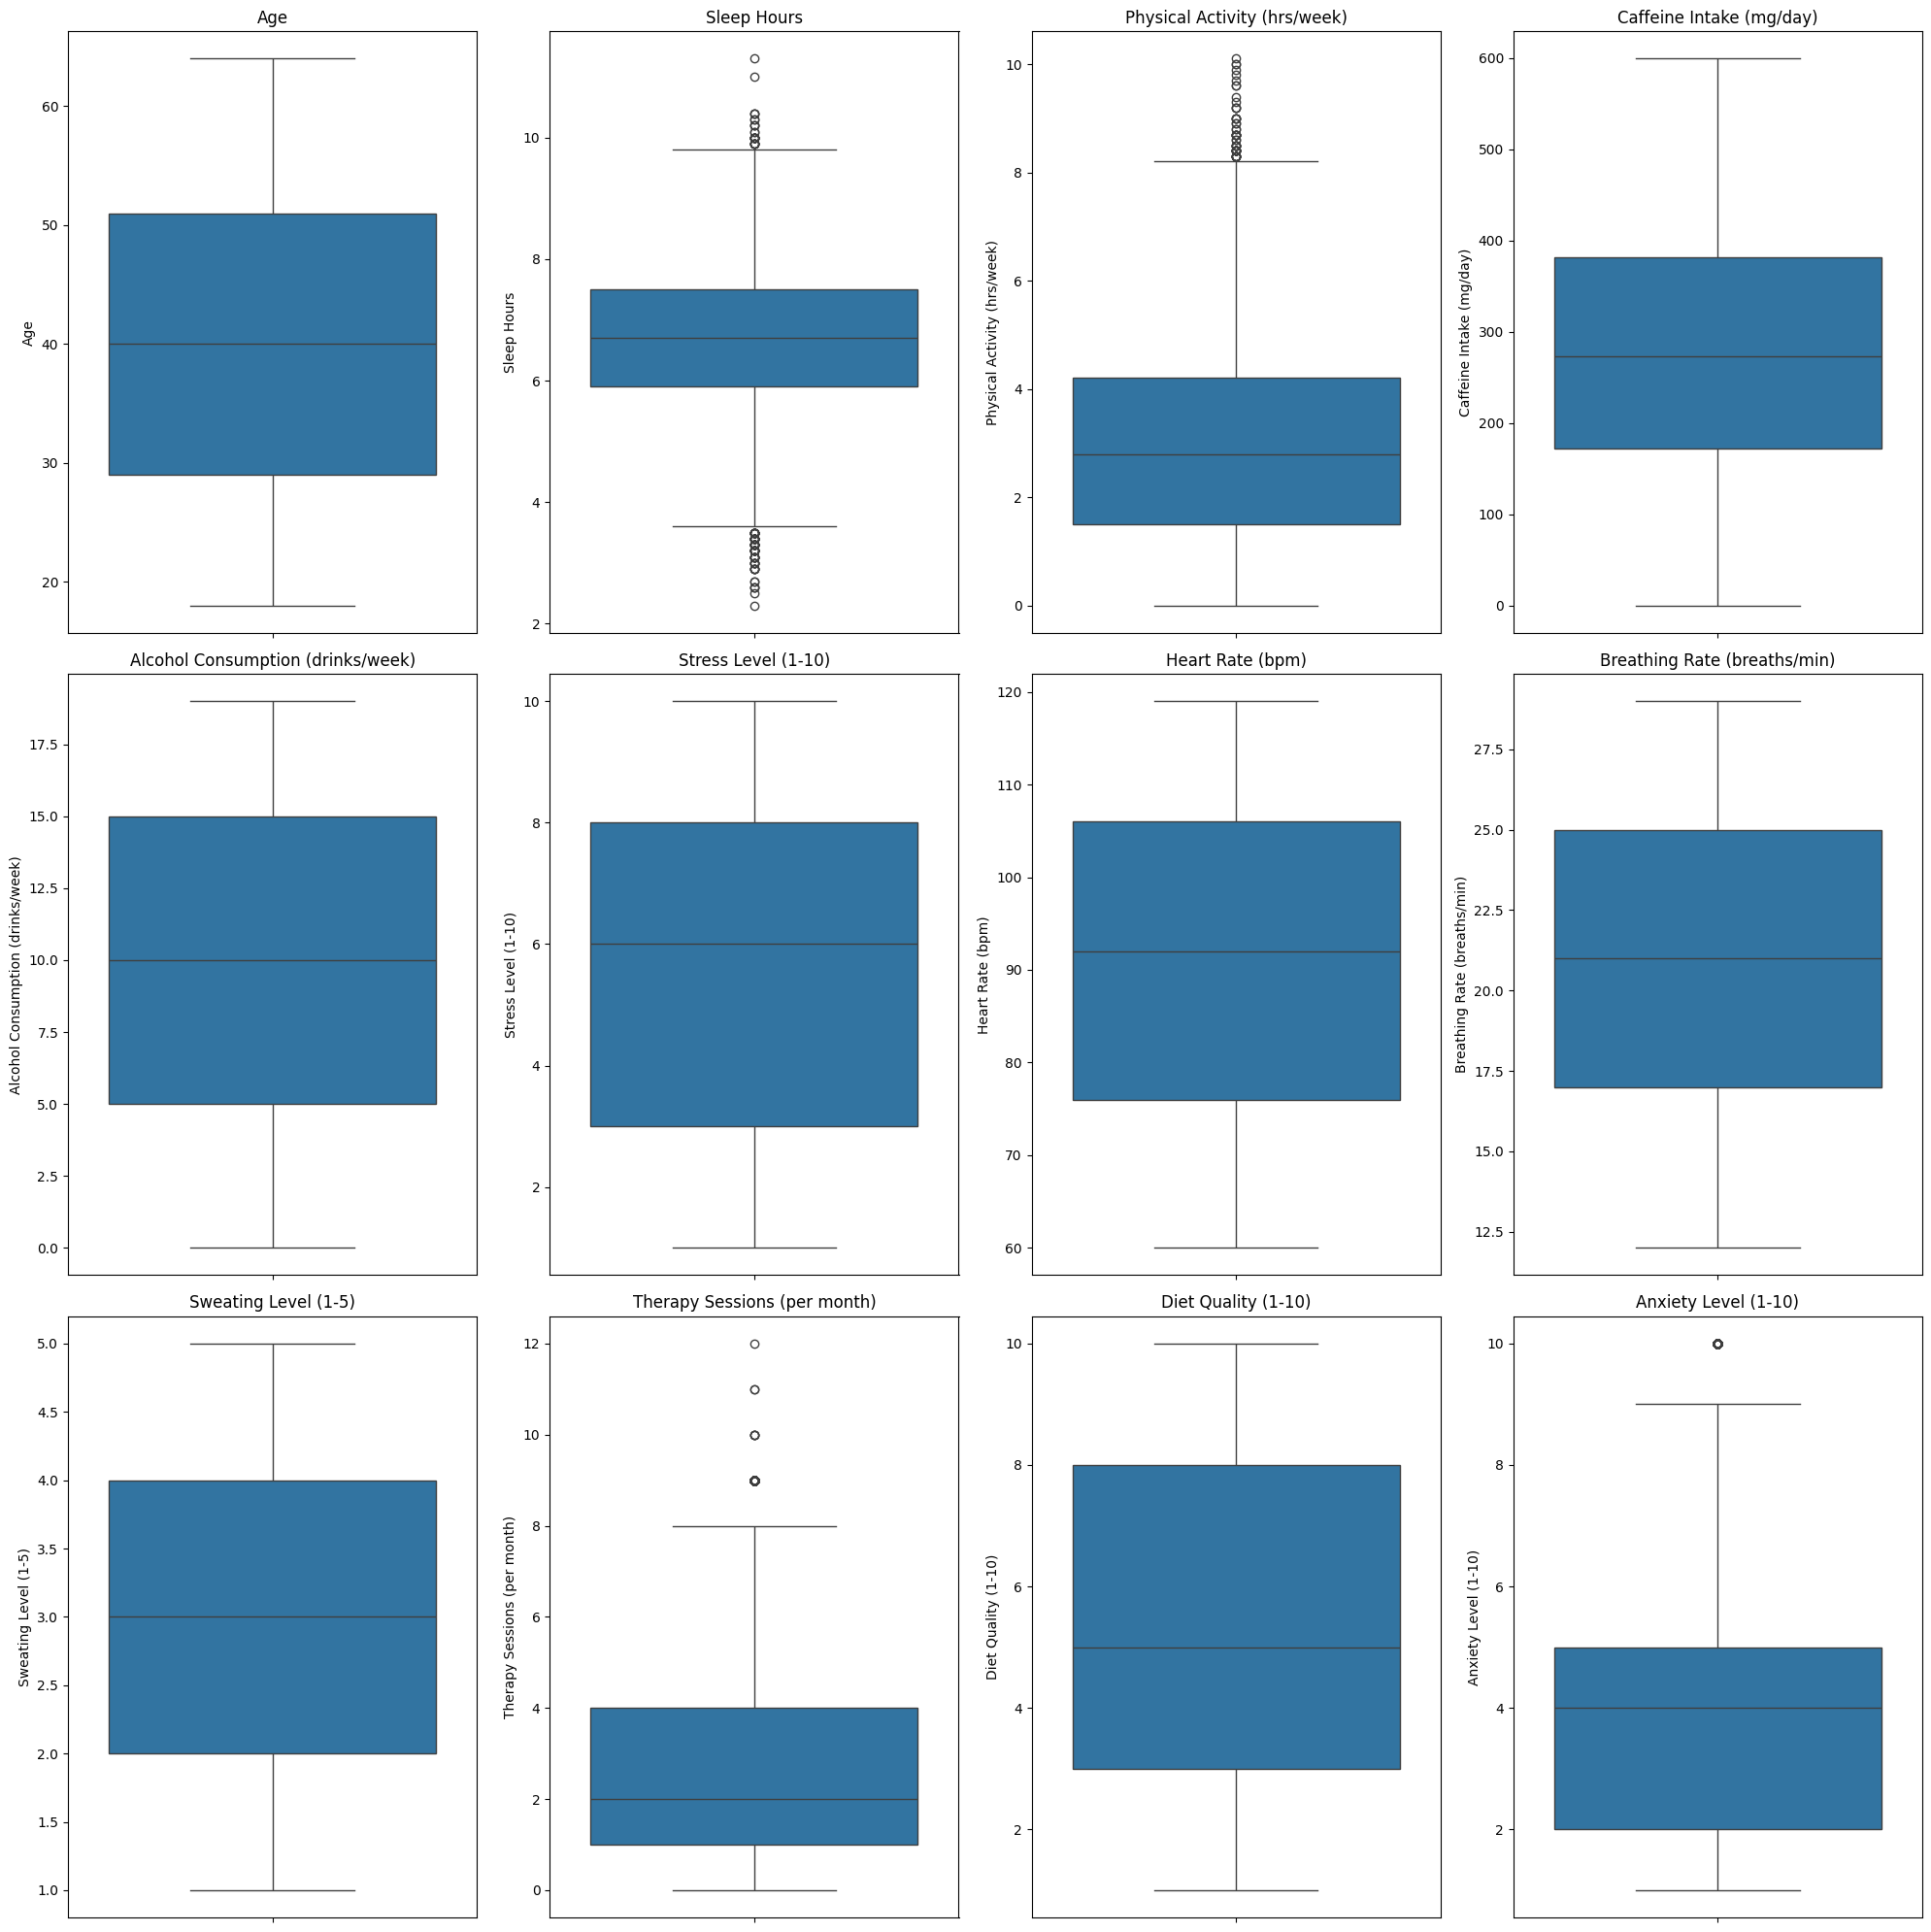

In [63]:
from typing import List, Tuple, Optional
import numpy as np
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import seaborn as sns

def graf_outliers(data:pd.DataFrame, rows:int=1, names: Optional[List[str]]=None) -> Tuple[Figure, np.ndarray]:
    if names is None:
        names = data.select_dtypes(include=["number"]).columns.tolist()
    if not names:
        raise ValueError("No presenta variables numéricas")
    plots = len(names)
    rows = rows
    cols = plots//rows + (plots%rows > 0)
    fig, ax = plt.subplots(rows, cols, figsize=(20,20))
    ax = ax.ravel()
    for i, name in enumerate(names):
        sns.boxplot(data, y=name, ax=ax[i])
        ax[i].set_title(name)
    fig.tight_layout()
    return fig, ax

fig, ax = graf_outliers(df_ansiety.select_dtypes(include=["number"]), rows=3)

## Categorización del nivel de ansiedad

In [64]:
bins = [1,4,8,10]
labels = ["bajo","medio","alto"]

df_ansiety["level"] = pd.cut(df_ansiety["Anxiety Level (1-10)"], include_lowest=True, bins=bins, labels=labels)

## Segmentando las profesiones a evaluar

In [65]:
occupations = ["Doctor","Engineer","Lawyer","Teacher","Scientist"]
df_ansiety_filter = df_ansiety.loc[df_ansiety["Occupation"].isin(occupations)]

## Separando las muestras de entrenamiento y prueba (validación)
### Para evitar **data leakage**, se excluyeron algunas variables fisiológicas directamente relacionadas con síntomas de ansiedad (frecuencia cardíaca, respiración, sudoración, etc.).

In [66]:
from sklearn.model_selection import train_test_split

X = df_ansiety_filter.drop(["Anxiety Level (1-10)","level","Stress Level (1-10)","Heart Rate (bpm)","Breathing Rate (breaths/min)",
                            "Sweating Level (1-5)","Dizziness", "Medication"], axis=1)
y = df_ansiety_filter["level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3298, 12), (825, 12), (3298,), (825,))

In [67]:
y_train.value_counts()

level
bajo     2191
medio     909
alto      198
Name: count, dtype: int64

## Pipeline de preprocesamiento, balanceo de clases (SMOTENC) y clasificación con Random Forest

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

cat_columns = X_train.select_dtypes(exclude=np.number).columns
preprocessor_1 = ColumnTransformer([("oe", OrdinalEncoder(), cat_columns)
                                   ], remainder="passthrough", force_int_remainder_cols=False)

cat_idx = list(range(len(cat_columns)))
smotenc = SMOTENC(categorical_features=cat_idx, random_state=42)

preprocessor_2 = ColumnTransformer([("ohe", OneHotEncoder(handle_unknown="ignore"), cat_idx)],
                                  remainder="passthrough", )

pipeline_rf = Pipeline([("ordinal_encoding", preprocessor_1),
                     ("smote", smotenc),
                     ("onehot_encoding", preprocessor_2),
                     ("model", RandomForestClassifier(random_state=42,class_weight="balanced"))])

pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('ordinal_encoding',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('oe', OrdinalEncoder(),
                                                  Index(['Gender', 'Occupation', 'Smoking', 'Family History of Anxiety',
       'Recent Major Life Event'],
      dtype='object'))])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4],
                         random_state=42)),
                ('onehot_encoding',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [0, 1, 2, 3, 4])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

### Evaluación del modelo mediante validación cruzada

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X_train, y_train, cv=skf,
                        scoring=["accuracy", "f1_macro", "f1_weighted", "roc_auc_ovr"],
                        return_train_score=False)

print({k: scores[k].mean().round(4) for k in scores if k.startswith('test_')})

{'test_accuracy': np.float64(0.6622), 'test_f1_macro': np.float64(0.6032), 'test_f1_weighted': np.float64(0.6457), 'test_roc_auc_ovr': np.float64(0.7434)}


## Métricas del modelo clasificación - Random Forest

### precision / recall / f1-score

In [70]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
y_predict = pipeline.predict(X_test)
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

        alto       0.70      0.90      0.79        49
        bajo       0.74      0.83      0.78       548
       medio       0.34      0.21      0.26       228

    accuracy                           0.67       825
   macro avg       0.59      0.65      0.61       825
weighted avg       0.62      0.67      0.64       825



### Matriz de confusión

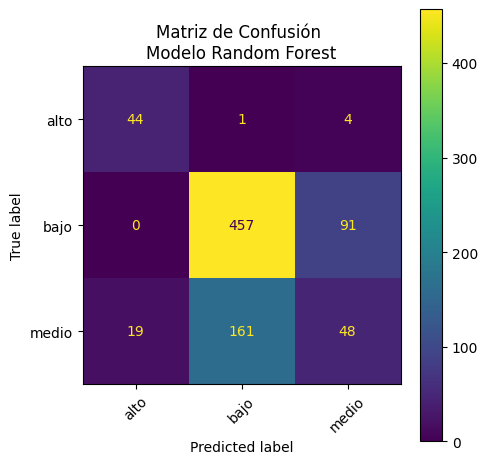

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5,5))
cm = confusion_matrix(y_test, y_predict)
ConfusionMatrixDisplay(cm, display_labels=pipeline.named_steps["model"].classes_).plot(ax=ax)
plt.title("Matriz de Confusión \nModelo Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Curva AUC-ROC

AUC por clase (OVR):
Clase alto: AUC = 0.987
Clase bajo: AUC = 0.680
Clase medio: AUC = 0.563


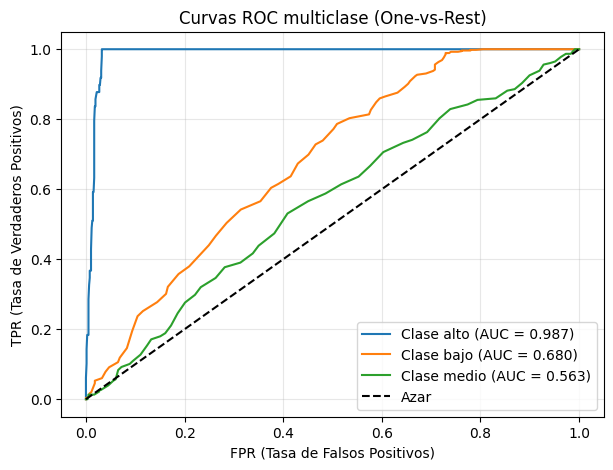

In [72]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba = pipeline.predict_proba(X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:,i], y_proba[:,i])
    roc_auc[c] = auc(fpr[c], tpr[c])

print("AUC por clase (OVR):")
for c in classes:
    print(f"Clase {c}: AUC = {roc_auc[c]:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
for c in classes:
    plt.plot(fpr[c], tpr[c], label=f'Clase {c} (AUC = {roc_auc[c]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.title('Curvas ROC multiclase (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Pipeline de preprocesamiento, balanceo de clases (SMOTENC) y clasificación con XGBClassifier

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder, LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

cat_columns = X_train.select_dtypes(exclude=np.number).columns
preprocessor_1 = ColumnTransformer([("oe", OrdinalEncoder(), cat_columns)
                                   ], remainder="passthrough", force_int_remainder_cols=False)

cat_idx = list(range(len(cat_columns)))
smotenc = SMOTENC(categorical_features=cat_idx, random_state=42)

preprocessor_2 = ColumnTransformer([("ohe", OneHotEncoder(handle_unknown="ignore"), cat_idx)],
                                  remainder="passthrough", )

pipeline_xgb = Pipeline([("ordinal_encoding", preprocessor_1),
                     ("smote", smotenc),
                     ("onehot_encoding", preprocessor_2),
                     ("model", XGBClassifier(random_state=42))])

pipeline_xgb.fit(X_train, y_train_le)

Pipeline(steps=[('ordinal_encoding',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('oe', OrdinalEncoder(),
                                                  Index(['Gender', 'Occupation', 'Smoking', 'Family History of Anxiety',
       'Recent Major Life Event'],
      dtype='object'))])),
                ('smote',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4],
                         random_state=42)),
                ('onehot_encoding',
                 ColumnTra...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Evaluación del modelo mediante validación cruzada

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline_xgb, X_train, y_train_le, cv=skf,
                        scoring=["accuracy", "f1_macro", "f1_weighted", "roc_auc_ovr"],
                        return_train_score=False)

print({k: scores[k].mean().round(4) for k in scores if k.startswith('test_')})

{'test_accuracy': np.float64(0.6731), 'test_f1_macro': np.float64(0.5895), 'test_f1_weighted': np.float64(0.6433), 'test_roc_auc_ovr': np.float64(0.7344)}


## Métricas del modelo clasificación - XGBClassifier

### precision / recall / f1-score

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
y_predict = pipeline_xgb.predict(X_test)
print(classification_report(y_test_le, y_predict, target_names=le_y.classes_))

              precision    recall  f1-score   support

        alto       0.70      0.88      0.78        49
        bajo       0.74      0.90      0.81       548
       medio       0.39      0.16      0.23       228

    accuracy                           0.70       825
   macro avg       0.61      0.65      0.61       825
weighted avg       0.64      0.70      0.65       825



### Matriz de confusión

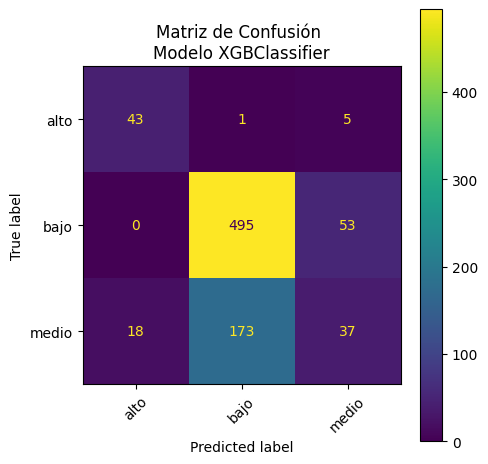

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5,5))
cm = confusion_matrix(y_test_le, y_predict)
ConfusionMatrixDisplay(cm, display_labels=le_y.classes_).plot(ax=ax)
plt.title("Matriz de Confusión \nModelo XGBClassifier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Curva AUC-ROC

AUC por clase (OVR):
Clase alto: AUC = 0.985
Clase bajo: AUC = 0.652
Clase medio: AUC = 0.531


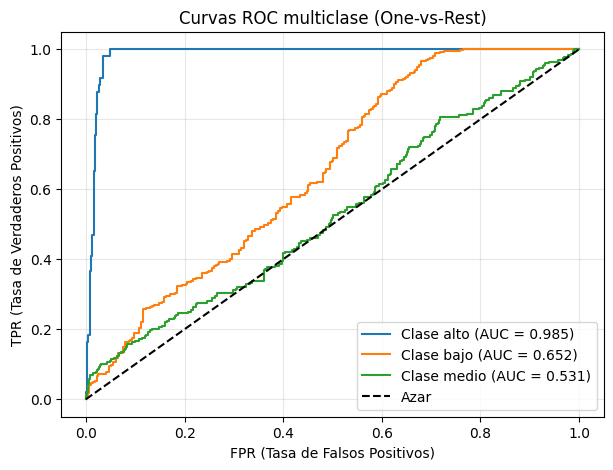

In [77]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba = pipeline_xgb.predict_proba(X_test)

classes = np.unique(y_test_le)
y_test_bin = label_binarize(y_test_le, classes=classes)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_test_bin[:,i], y_proba[:,i])
    roc_auc[c] = auc(fpr[c], tpr[c])

print("AUC por clase (OVR):")
for i, c in zip(le_y.classes_.tolist(), classes):
    print(f"Clase {i}: AUC = {roc_auc[c]:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
for i, c in zip(le_y.classes_.tolist(), classes):
    plt.plot(fpr[c], tpr[c], label=f'Clase {i} (AUC = {roc_auc[c]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('FPR (Tasa de Falsos Positivos)')
plt.ylabel('TPR (Tasa de Verdaderos Positivos)')
plt.title('Curvas ROC multiclase (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Análisis de los resultados que fueron aplicados a la muestra de prueba (validación) con el modelo de Random Forest

### **Desbalance de clases de la muestra de prueba**
- bajo: 66%
- medio: 28%
- alto: 6%

### **Rendimiento por clase**
- **alto:**
    - **Recall**=0.90 -> Detecta muy bien los casos reales de ansiedad en un nivel alto (44 de 49).
    - **Precision**=0.70 -> Cuando predice el nivel de ansiedad alto, acierta el 70% de veces.
    - **AUC**=0.987 -> muy buena separabilidad, aunque con pocos casos.
    
- **El modelo distingue muy bien los casos de ansiedad de un nivel alto. Probablemente porque tiene características bien definidad.**

- **bajo:**
    - **Recall**=0.83 -> Detecta razonablemente bien los casos reales de ansiedad en un nivel bajo (457 de 548).
    - **Precision**=0.74 -> Cuando predice el nivel de ansiedad bajo, acierta el 74% de veces.
    - **AUC**=0.680 -> muestra una separabilidad moderada.

- **Siendo la clase mayoritaria (548 casos). El modelo funciona razonablemente bien**

- **medio:**
    - **Recall**=0.21 -> No muestra una buena detección de los casos reales de ansiedad en un nivel medio (48 de 228).
    - **Precision**=0.34 -> Cuando predice el nivel de ansiedad alto, acierta el 36% de veces.
    - **AUC**=0.563 -> casi al azar (aleatorio), muy baja separabilidad.

- **El modelo tiene muchas dificultades para detectar el nivel de ansiedad media.**

## Análisis de los resultados que fueron aplicados a la muestra de prueba (validación) con el modelo de XGBClassifier

### **Desbalance de clases**
- bajo: 66%
- medio: 28%
- alto: 6%

### **Rendimiento por clase**
- **alto:**
    - **Recall**=0.88 -> Detecta bien los casos reales de ansiedad en un nivel alto (43 de 49).
    - **Precision**=0.70 -> Cuando predice el nivel de ansiedad alto, acierta el 67% de veces.
    - **AUC**=0.985 -> muy buena separabilidad, aunque con pocos casos.
    
- **El modelo distingue muy bien los casos de ansiedad de un nivel alto. Probablemente porque tiene características bien definidad.**

- **bajo:**
    - **Recall**=0.90 -> Detecta razonablemente bien los casos reales de ansiedad en un nivel bajo (495 de 548).
    - **Precision**=0.74 -> Cuando predice el nivel de ansiedad bajo, acierta el 75% de veces.
    - **AUC**=0.652 -> muestra una separabilidad moderada.

- **Siendo la clase mayoritaria (548 casos). El modelo funciona razonablemente bien**

- **medio:**
    - **Recall**=0.16 -> No muestra una buena detección de los casos reales de ansiedad en un nivel medio (37 de 228).
    - **Precision**=0.39 -> Cuando predice el nivel de ansiedad alto, acierta el 39% de veces.
    - **AUC**=0.531 -> casi al azar (aleatorio), muy baja separabilidad.

- **El modelo tiene muchas dificultades para detectar el nivel de ansiedad media.**